# SC2001 Project 2 — Dijkstra's Algorithm

This notebook implements and compares the two versions required by the project:

- **Part (a):** adjacency matrix + array priority queue
- **Part (b):** adjacency list + minimizing heap
- **Part (c):** empirical comparison across different numbers of vertices and edges

All generated edge weights are positive, as required by Dijkstra's algorithm.


In [2]:
import heapq
import random
import time
import statistics as stats
import matplotlib.pyplot as plt

INF = float('inf')


# Part (a) — Adjacency Matrix + Array Priority Queue

The priority queue is represented directly by the Python list `pq`.

To extract the minimum, the algorithm scans the array and finds the queued vertex with the smallest current distance.


In [3]:
def dijkstra_matrix(adjMatrix, source):
    n = len(adjMatrix)

    dist = [INF] * n
    dist[source] = 0

    # Array-based priority queue
    pq = list(range(n))
    in_queue = [True] * n

    while pq:
        # Find queued vertex with minimum distance
        min_index = 0
        for i in range(1, len(pq)):
            if dist[pq[i]] < dist[pq[min_index]]:
                min_index = i

        current_vertex = pq.pop(min_index)
        in_queue[current_vertex] = False

        # Remaining vertices are unreachable
        if dist[current_vertex] == INF:
            break

        # Scan the whole matrix row
        for neighbour in range(n):
            weight = adjMatrix[current_vertex][neighbour]

            if (
                weight != INF
                and current_vertex != neighbour
                and in_queue[neighbour]
            ):
                new_dist = dist[current_vertex] + weight

                if new_dist < dist[neighbour]:
                    dist[neighbour] = new_dist

    return dist


## Part (a) sample graph

In [4]:
# A=0, B=1, C=2, D=3, E=4, F=5, G=6, H=7
adjMatrix = [
    [0,   4,   2,   INF, 7,   INF, INF, INF],
    [4,   0,   INF, 1,   INF, 6,   INF, INF],
    [2,   INF, 0,   3,   5,   INF, INF, INF],
    [INF, 1,   3,   0,   INF, 4,   8,   INF],
    [7,   INF, 5,   INF, 0,   INF, 2,   9],
    [INF, 6,   INF, 4,   INF, 0,   3,   5],
    [INF, INF, INF, 8,   2,   3,   0,   1],
    [INF, INF, INF, INF, 9,   5,   1,   0]
]

dist_a = dijkstra_matrix(adjMatrix, 0)

print("Distances from A:", dist_a)


Distances from A: [0, 4, 2, 5, 7, 9, 9, 10]


## Part (a) theoretical complexity

Let \(n=|V|\).

- The array priority queue contains at most \(|V|\) vertices.
- Finding the minimum vertex requires scanning the queue: \(O(|V|)\).
- This happens once for each vertex: \(O(|V|^2)\).
- With an adjacency matrix, processing a vertex scans an entire row of \(|V|\) entries.
- Across all vertices, matrix scanning is also \(O(|V|^2)\).

Therefore:

\[
\boxed{T_A(|V|,|E|)=O(|V|^2)}
\]

The runtime is mainly determined by \(|V|\), even when the graph is sparse, because the adjacency matrix still contains \(|V|^2\) entries.

Space complexity:

\[
\boxed{O(|V|^2)}
\]


# Part (b) — Adjacency List + Min-Heap

Each adjacency-list entry stores `(neighbour, weight)`.

Python's `heapq` is used as the minimizing heap. Each heap entry is `(distance, vertex)`, so the smallest distance is removed first.


In [5]:
def dijkstra_list(adjList, source):
    n = len(adjList)

    dist = [INF] * n
    dist[source] = 0

    # Min-heap priority queue: (distance, vertex)
    pq = [(0, source)]

    while pq:
        current_distance, current_vertex = heapq.heappop(pq)

        # Ignore an outdated heap entry
        if current_distance > dist[current_vertex]:
            continue

        for neighbour, weight in adjList[current_vertex]:
            new_dist = current_distance + weight

            if new_dist < dist[neighbour]:
                dist[neighbour] = new_dist
                heapq.heappush(pq, (new_dist, neighbour))

    return dist


## Part (b) sample graph

In [6]:
# Same graph as Part (a), now stored as an adjacency list
adjList = [
    [(1, 4), (2, 2), (4, 7)],          # A = 0
    [(0, 4), (3, 1), (5, 6)],          # B = 1
    [(0, 2), (3, 3), (4, 5)],          # C = 2
    [(1, 1), (2, 3), (5, 4), (6, 8)],  # D = 3
    [(0, 7), (2, 5), (6, 2), (7, 9)],  # E = 4
    [(1, 6), (3, 4), (6, 3), (7, 5)],  # F = 5
    [(3, 8), (4, 2), (5, 3), (7, 1)],  # G = 6
    [(4, 9), (5, 5), (6, 1)]           # H = 7
]

dist_b = dijkstra_list(adjList, 0)

print("Distances from A:", dist_b)


Distances from A: [0, 4, 2, 5, 7, 9, 9, 10]


## Part (b) theoretical complexity

With an adjacency list, only edges that actually exist are examined.

For a binary min-heap:

- heap insertion/removal costs \(O(\log |V|)\),
- adjacency-list scanning examines \(O(|E|)\) edges overall.

Therefore:

\[
\boxed{T_B(|V|,|E|)=O((|V|+|E|)\log |V|)}
\]

For a connected graph, \(|E|\ge |V|-1\), so this is commonly written as:

\[
\boxed{O(|E|\log |V|)}
\]

Space complexity:

\[
\boxed{O(|V|+|E|)}
\]


# Correctness check — both implementations on the same graph

In [7]:
print("Part A:", dist_a)
print("Part B:", dist_b)
print("Same distances:", dist_a == dist_b)


Part A: [0, 4, 2, 5, 7, 9, 9, 10]
Part B: [0, 4, 2, 5, 7, 9, 9, 10]
Same distances: True


# Empirical Analysis

For a fair comparison:

1. The **same random graph** is generated in both representations.
2. Graph generation is **not included** in the measured Dijkstra runtime.
3. Each configuration is run several times and the **mean runtime** is used.
4. The generated graphs are connected and use positive integer weights from 1 to 10.
5. \(|E|\) below means the number of **unique undirected edges**, not the doubled number of adjacency-list entries.


In [8]:
def generate_graph_both(n, density=0.3, seed=None):
    rng = random.Random(seed)

    matrix = [[INF] * n for _ in range(n)]
    adj = [[] for _ in range(n)]

    for i in range(n):
        matrix[i][i] = 0

    # Maximum number of unique edges in a simple undirected graph
    max_edges = n * (n - 1) // 2
    target_edges = max(n - 1, round(density * max_edges))

    # First add a path so the graph is connected
    for i in range(n - 1):
        weight = rng.randint(1, 10)
        matrix[i][i + 1] = weight
        matrix[i + 1][i] = weight
        adj[i].append((i + 1, weight))
        adj[i + 1].append((i, weight))

    edge_count = n - 1

    # Probability chosen so expected total edge count is close to target_edges
    remaining_pairs = max_edges - (n - 1)
    remaining_needed = target_edges - (n - 1)

    if remaining_pairs > 0:
        probability = remaining_needed / remaining_pairs
    else:
        probability = 0

    for i in range(n):
        for j in range(i + 2, n):
            if rng.random() < probability:
                weight = rng.randint(1, 10)
                matrix[i][j] = weight
                matrix[j][i] = weight
                adj[i].append((j, weight))
                adj[j].append((i, weight))
                edge_count += 1

    return matrix, adj, edge_count


In [9]:
def benchmark(n, density, reps=5, seed=1000):
    matrix_times = []
    heap_times = []
    edge_counts = []

    for r in range(reps):
        matrix, adj, edges = generate_graph_both(
            n,
            density=density,
            seed=seed + r
        )

        # Alternate execution order to reduce systematic timing bias
        if r % 2 == 0:
            start = time.perf_counter()
            result_a = dijkstra_matrix(matrix, 0)
            matrix_times.append(time.perf_counter() - start)

            start = time.perf_counter()
            result_b = dijkstra_list(adj, 0)
            heap_times.append(time.perf_counter() - start)
        else:
            start = time.perf_counter()
            result_b = dijkstra_list(adj, 0)
            heap_times.append(time.perf_counter() - start)

            start = time.perf_counter()
            result_a = dijkstra_matrix(matrix, 0)
            matrix_times.append(time.perf_counter() - start)

        # Both algorithms must solve the same graph correctly
        assert result_a == result_b

        edge_counts.append(edges)

    return (
        stats.mean(matrix_times),
        stats.mean(heap_times),
        round(stats.mean(edge_counts))
    )


# Experiment 1 — Runtime vs Number of Vertices

|V|=  50  |E|≈   370  Matrix=0.000243s  Heap=0.000068s
|V|= 100  |E|≈  1490  Matrix=0.000860s  Heap=0.000207s
|V|= 200  |E|≈  5967  Matrix=0.003385s  Heap=0.000964s
|V|= 300  |E|≈ 13481  Matrix=0.005994s  Heap=0.001410s
|V|= 400  |E|≈ 23989  Matrix=0.010153s  Heap=0.002483s
|V|= 500  |E|≈ 37442  Matrix=0.016102s  Heap=0.004578s


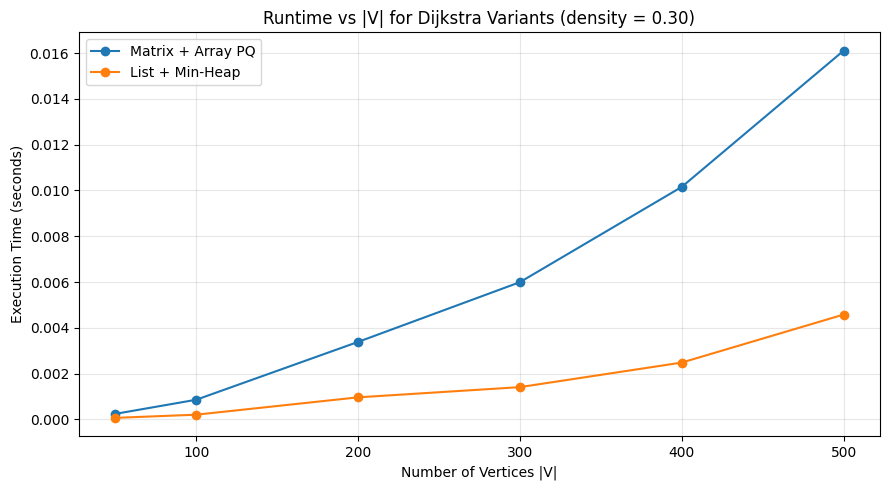

In [10]:
vertex_sizes = [50, 100, 200, 300, 400, 500]
fixed_density = 0.30

matrix_vertex_times = []
heap_vertex_times = []

for n in vertex_sizes:
    t_matrix, t_heap, edges = benchmark(
        n,
        density=fixed_density,
        reps=5,
        seed=1000 + n
    )

    matrix_vertex_times.append(t_matrix)
    heap_vertex_times.append(t_heap)

    print(
        f"|V|={n:4d}  |E|≈{edges:6d}  "
        f"Matrix={t_matrix:.6f}s  Heap={t_heap:.6f}s"
    )

plt.figure(figsize=(9, 5))
plt.plot(vertex_sizes, matrix_vertex_times, marker='o', label='Matrix + Array PQ')
plt.plot(vertex_sizes, heap_vertex_times, marker='o', label='List + Min-Heap')
plt.xlabel('Number of Vertices |V|')
plt.ylabel('Execution Time (seconds)')
plt.title('Runtime vs |V| for Dijkstra Variants (density = 0.30)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


At fixed density, increasing \(|V|\) also increases \(|E|\). The graph shows how the two complete implementations scale as the graph becomes larger.


# Experiment 2 — Runtime vs Number of Edges

In [11]:
fixed_n = 400
edge_densities = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.95]

edge_counts = []
matrix_edge_times = []
heap_edge_times = []

for density in edge_densities:
    t_matrix, t_heap, edges = benchmark(
        fixed_n,
        density=density,
        reps=5,
        seed=2000 + round(density * 100)
    )

    edge_counts.append(edges)
    matrix_edge_times.append(t_matrix)
    heap_edge_times.append(t_heap)

    print(
        f"density={density:.2f}  |E|≈{edges:6d}  "
        f"Matrix={t_matrix:.6f}s  Heap={t_heap:.6f}s"
    )


density=0.05  |E|≈  4009  Matrix=0.007973s  Heap=0.000650s
density=0.10  |E|≈  7902  Matrix=0.008669s  Heap=0.001443s
density=0.20  |E|≈ 15938  Matrix=0.009569s  Heap=0.001968s
density=0.40  |E|≈ 31914  Matrix=0.011447s  Heap=0.003725s
density=0.60  |E|≈ 47802  Matrix=0.012185s  Heap=0.005547s
density=0.80  |E|≈ 63774  Matrix=0.012301s  Heap=0.006703s
density=0.95  |E|≈ 75813  Matrix=0.013307s  Heap=0.008790s


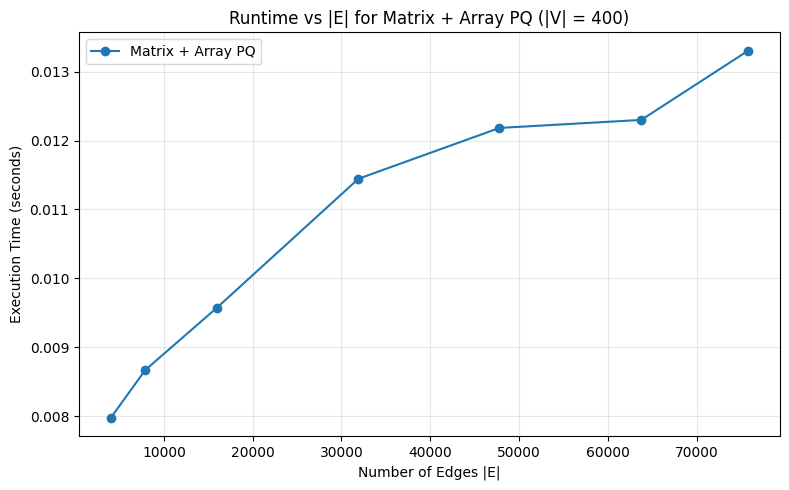

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(edge_counts, matrix_edge_times, marker='o', label='Matrix + Array PQ')
plt.xlabel('Number of Edges |E|')
plt.ylabel('Execution Time (seconds)')
plt.title('Runtime vs |E| for Matrix + Array PQ (|V| = 400)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


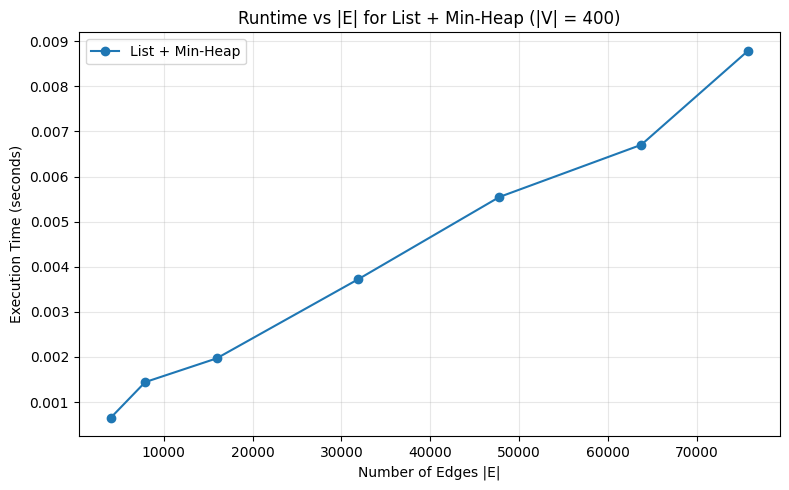

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(edge_counts, heap_edge_times, marker='o', label='List + Min-Heap')
plt.xlabel('Number of Edges |E|')
plt.ylabel('Execution Time (seconds)')
plt.title('Runtime vs |E| for List + Min-Heap (|V| = 400)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


With \(|V|\) fixed, the matrix implementation still scans approximately the same \(|V|^2\) matrix entries. The adjacency-list implementation does more work as \(|E|\) increases because more neighbours must be examined.


# Experiment 3 — Sparse vs Dense Graphs

In [14]:
comparison_nodes = [100, 200, 300, 400, 500, 600, 800, 1000]

density_cases = {
    'Sparse': 0.05,
    'Dense': 0.90
}

comparison_results = {}

for name, density in density_cases.items():
    matrix_times = []
    heap_times = []

    for n in comparison_nodes:
        t_matrix, t_heap, edges = benchmark(
            n,
            density=density,
            reps=3,
            seed=3000 + n
        )

        matrix_times.append(t_matrix)
        heap_times.append(t_heap)

    comparison_results[name] = (matrix_times, heap_times)


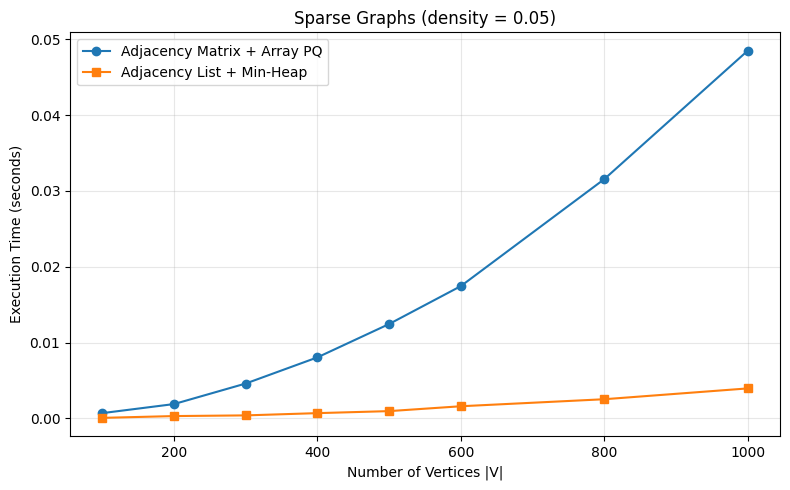

In [15]:
matrix_times, heap_times = comparison_results['Sparse']

plt.figure(figsize=(8, 5))
plt.plot(comparison_nodes, matrix_times, marker='o', label='Adjacency Matrix + Array PQ')
plt.plot(comparison_nodes, heap_times, marker='s', label='Adjacency List + Min-Heap')
plt.xlabel('Number of Vertices |V|')
plt.ylabel('Execution Time (seconds)')
plt.title('Sparse Graphs (density = 0.05)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


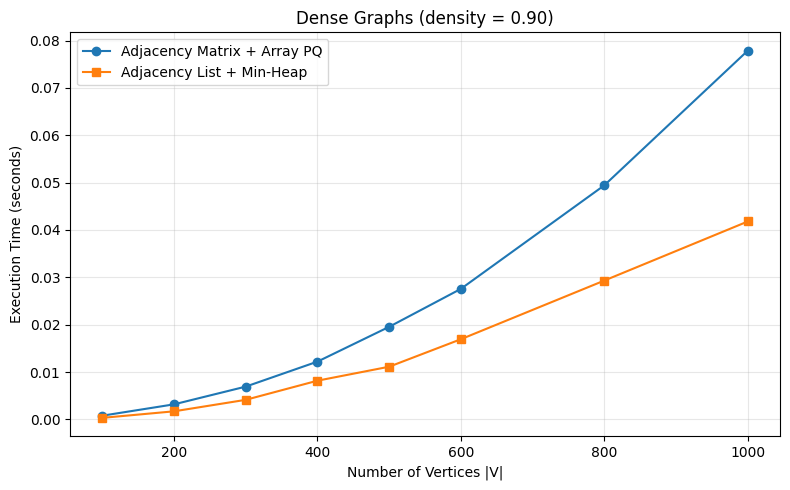

In [16]:
matrix_times, heap_times = comparison_results['Dense']

plt.figure(figsize=(8, 5))
plt.plot(comparison_nodes, matrix_times, marker='o', label='Adjacency Matrix + Array PQ')
plt.plot(comparison_nodes, heap_times, marker='s', label='Adjacency List + Min-Heap')
plt.xlabel('Number of Vertices |V|')
plt.ylabel('Execution Time (seconds)')
plt.title('Dense Graphs (density = 0.90)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Part (c) — Comparison

| Aspect | Part (a): Matrix + Array PQ | Part (b): List + Min-Heap |
|---|---|---|
| Graph storage | Adjacency matrix | Adjacency list |
| Priority queue | Unsorted array | Binary min-heap |
| Time complexity | \(O(|V|^2)\) | \(O((|V|+|E|)\log |V|)\) |
| Space complexity | \(O(|V|^2)\) | \(O(|V|+|E|)\) |
| Sparse graphs | Wastes time/space scanning missing edges | Usually preferable |
| Dense graphs | Becomes more competitive | Heap/list overhead becomes more significant |

## Discussion

**Sparse graphs:** Part (b) is normally the better choice. An adjacency list stores and scans only existing edges, so when \(|E|\ll |V|^2\), it avoids most of the work performed by the matrix version.

**Dense graphs:** As \(|E|\) approaches \(|V|^2\), the advantage of the adjacency list becomes smaller. Both representations must process a large amount of edge information, while the min-heap also introduces \(O(\log |V|)\) operations. In this case, Part (a) can become competitive or faster in practice.

**Memory:** Part (b) is generally more memory-efficient, especially for sparse graphs. Part (a) always requires a \(|V|\times|V|\) matrix regardless of how many edges actually exist.

**Empirical timings:** Exact measured times depend on the computer, Python version, and random graphs. The important result is the overall scaling trend, not one exact timing value.


# Final Conclusion

- **Part (a)** is simple and has predictable \(O(|V|^2)\) runtime, but its adjacency matrix always uses \(O(|V|^2)\) memory.
- **Part (b)** uses \(O(|V|+|E|)\) graph storage and is usually more suitable for sparse graphs.
- There is no single implementation that is always fastest in practice: graph density determines which representation and priority queue are more suitable.
